## Run HDBSCAN algorithm on different sets of user features
- Baseline: users_fingerprint_norm
- Set 1a: user_embedding_svd_ability_seen_beh
- Set 1b: user_embedding_svd_ability_seen_beh_B
- Set 2a: user_embedding_svd512_ae128_plus_beh
- Set 2b: user_embedding_svd512_ae128_plus_beh_B
- Set 3: user_fingerprint_B_lex_clusters_scaled

In [1]:
import sys
sys.path.append("..")

%load_ext autoreload
%autoreload 2

### Load datasets

In [2]:
import pandas as pd

df_base = pd.read_csv("../data/users_fingerprint_norm.csv").set_index("user_id").drop(columns=["Unnamed: 0"])
df_1a = pd.read_csv("../data/user_embedding_svd_ability_seen_beh.csv").set_index("user_id")
df_1b = pd.read_csv("../data/user_embedding_svd_ability_seen_beh_B.csv").set_index("user_id")
df_2a = pd.read_csv("../data/user_embedding_svd512_ae128_plus_beh.csv").set_index("user_id")
df_2b = pd.read_csv("../data/user_embedding_svd512_ae128_plus_beh_B.csv").set_index("user_id")
df_3 = pd.read_csv("../data/user_fingerprint_B_lex_clusters_scaled.csv").set_index("user_id").drop(columns=["Unnamed: 0"])

print(df_base.shape)
print(df_1a.shape)
print(df_1b.shape)
print(df_2a.shape)
print(df_2b.shape)
print(df_3.shape)

(2709, 5633)
(2709, 99)
(2709, 99)
(2709, 131)
(2709, 131)
(2709, 165)


In [3]:
from src.evaluation.metrics import hopkins_statistic

for df in [df_base, df_1a, df_1b, df_2a, df_2b, df_3]:
    score = hopkins_statistic(df.values)
    print(f"Hopkins Statistic: {score:.4f}")

## ~= 0.5 means mostly noise, -> 0 means grid-like not good for density-based clustering, -> 1 strong peaks and valleys in density ~= good for clustering

Hopkins Statistic: 0.9715
Hopkins Statistic: 0.8695
Hopkins Statistic: 0.8620
Hopkins Statistic: 0.7630
Hopkins Statistic: 0.7639
Hopkins Statistic: 0.9667


### Run HDBSCAN

In [5]:
!pip install hdbscan

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 1.6 MB/s  0:00:04m0:00:0100:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for hdbscan: filename=hdbscan-0.8.41-cp39-cp39-macosx_10_15_x86_64.whl size=697403 sha256=fce217a6611a98de1e6961adb27d595b2ea6b03bd021a1f51ab6386f88b6b934
  Stored in directory: /Users/andy/Library/Caches/pip/wheels/8a/25/ef/ea295bd6ff503043606cbf608f923aaa71b232730dfbef019a
Successfully built hdbscan


In [21]:
processed_df[processed_df['cluster_label'] <0]['soft_cluster_score'].describe()

count    1649.000000
mean        0.029102
std         0.011200
min         0.002021
25%         0.020754
50%         0.030967
75%         0.037981
max         0.055579
Name: soft_cluster_score, dtype: float64


--- Processing: train ---


/Users/andy/anaconda3/envs/datathon/lib/python3.9/site-packages/hdbscan/prediction.py:663: RuntimeWarning: invalid value encountered in scalar divide
  in_cluster_probs = all_points_prob_in_some_cluster(


Original Noise: 1348 (62.21%)
Soft Clustering has re-assigned all points to 19 clusters.
Saved results for train to '../data/tmp/hdbscan/' folder.


/Users/andy/anaconda3/envs/datathon/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


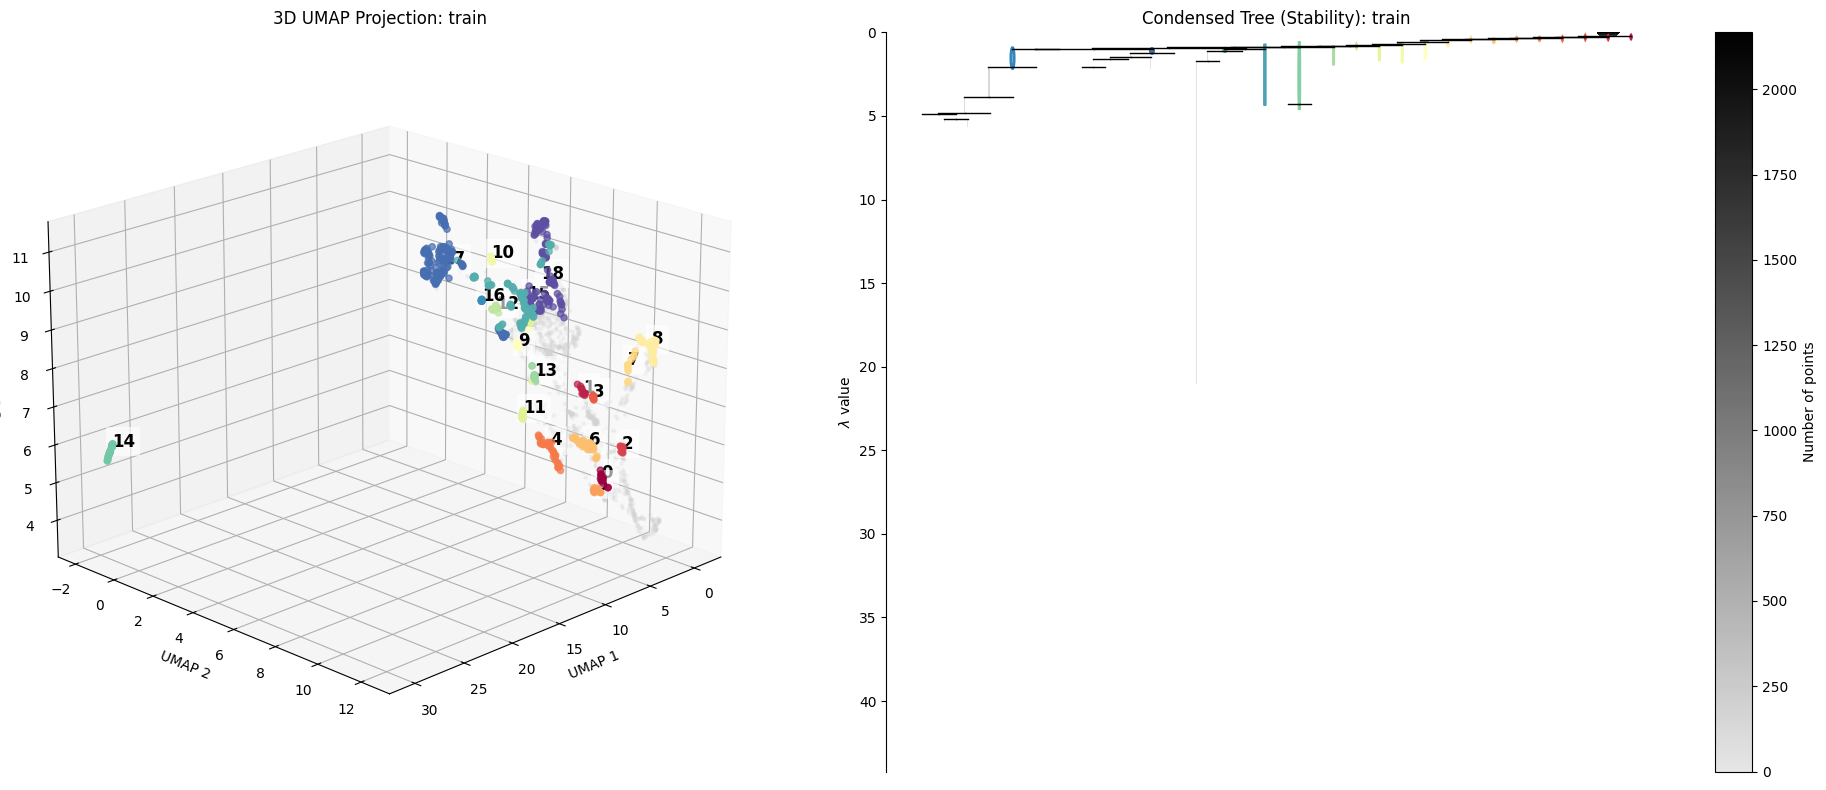

In [37]:
from src.models.HDBSCAN import run_hdbscan_pipeline, save_clustering_results, get_all_cluster_importances
from src.evaluation.visualize import visualize_hdbscan_with_labels, plot_cluster_top_features_boxplot, plot_cluster_top_features_radar, visualize_hdbscan_3d

# datasets = {
#     # "baseline": df_base, 
#     # "svd": df_1a, 
#     # "svd_B": df_1b,
#     # "svd512_ae128": df_2a, 
#     # "svd512_ae128_B": df_2b,
#     "lex_clusters_B": df_3,
# }

df_train = df_3.sample(frac=0.8)
df_test = df_3.loc[~df_3.index.isin(df_train.index)]

datasets = {
    # "test": df_test,
    "train": df_train
}


for name, df in datasets.items():
    print(f"\n--- Processing: {name} ---")
    
    # For the high-dim set, we ensure PCA/UMAP is used
    processed_df, model = run_hdbscan_pipeline(df.reset_index(), n_components=min(df.shape[1],200),
                                               epsilon=1.0, min_cluster_size=10, min_samples=2)
    
    save_clustering_results(processed_df, model, name, "../data/tmp/hdbscan")

    feature_cols = [c for c in processed_df.columns if c not in ['user_id', 'cluster_label', 'cluster_probability', 'soft_cluster_label', 'soft_cluster_score']]
    importance_dict = get_all_cluster_importances(processed_df, feature_cols)

    # processed_df.loc[(processed_df['cluster_label'] <0) & (processed_df['soft_cluster_score'] >0.037981), 'cluster_label'] = \
    #     processed_df.loc[(processed_df['cluster_label']) <0 & (processed_df['soft_cluster_score'] >0.037981), 'soft_cluster_label']

    visualize_hdbscan_3d(processed_df, model, name, "../data/tmp/hdbscan/plots")

#### See Top Features per cluster compared to global average

In [38]:
df_test

,max_history_seen,vocab_size,learning_speed,lex_cluster_0_ability,lex_cluster_0_seen,lex_cluster_10_ability,lex_cluster_10_seen,lex_cluster_11_ability,lex_cluster_11_seen,lex_cluster_12_ability,...,lex_cluster_79_ability,lex_cluster_79_seen,lex_cluster_7_ability,lex_cluster_7_seen,lex_cluster_80_ability,lex_cluster_80_seen,lex_cluster_8_ability,lex_cluster_8_seen,lex_cluster_9_ability,lex_cluster_9_seen
user_id,,,,,,,,,,,,,,,,,,,,,
u:0xw,-0.215139,0.781374,-0.905419,-0.205265,-0.154182,-0.156271,-0.125604,-0.203311,-0.167023,-0.269497,...,1.752848,1.036189,-0.193256,-0.110080,-0.663493,-0.403193,0.761556,0.039492,0.346511,-0.174184
u:7Wi,1.281016,-0.651657,1.403877,1.882882,0.602484,-0.156271,-0.125604,-0.203311,-0.167023,-0.269497,...,-0.229271,-0.201845,-0.193256,-0.110080,-0.663493,-0.403193,-0.592889,-0.333532,-0.530608,-0.232298
u:8GC,-0.452624,-0.041554,-0.957740,-0.205265,-0.154182,-0.156271,-0.125604,-0.203311,-0.167023,-0.269497,...,-0.229271,-0.201845,-0.193256,-0.110080,0.828727,-0.146857,1.434668,0.114096,-0.530608,-0.232298
u:A7G,0.212334,1.419854,-0.654540,-0.205265,-0.154182,-0.156271,-0.125604,-0.203311,-0.167023,4.036376,...,1.441672,0.210833,-0.193256,-0.110080,1.984133,0.878490,2.150730,0.487120,0.038903,-0.135441
u:ADl,-0.405127,-0.084120,-1.100208,-0.205265,-0.154182,12.253064,7.223450,-0.203311,-0.167023,-0.269497,...,-0.229271,-0.201845,2.693497,1.587492,-0.663493,-0.403193,-0.592889,-0.333532,-0.107490,-0.096699
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
u:tNb,-0.428875,-0.438830,1.651499,-0.205265,-0.154182,-0.156271,-0.125604,-0.203311,-0.167023,-0.269497,...,-0.229271,-0.201845,-0.193256,-0.110080,-0.663493,-0.403193,-0.592889,-0.333532,-0.530608,-0.232298
u:uC7,-0.001403,0.043576,0.411362,-0.205265,-0.154182,-0.156271,-0.125604,-0.203311,-0.167023,-0.269497,...,-0.229271,-0.201845,-0.193256,-0.110080,-0.663493,-0.403193,-0.592889,-0.333532,-0.530608,-0.232298
u:vPA,-0.286385,-0.438830,0.106402,-0.205265,-0.154182,-0.156271,-0.125604,-0.203311,-0.167023,-0.269497,...,-0.229271,-0.201845,-0.193256,-0.110080,-0.663493,-0.403193,-0.592889,-0.333532,-0.530608,-0.232298


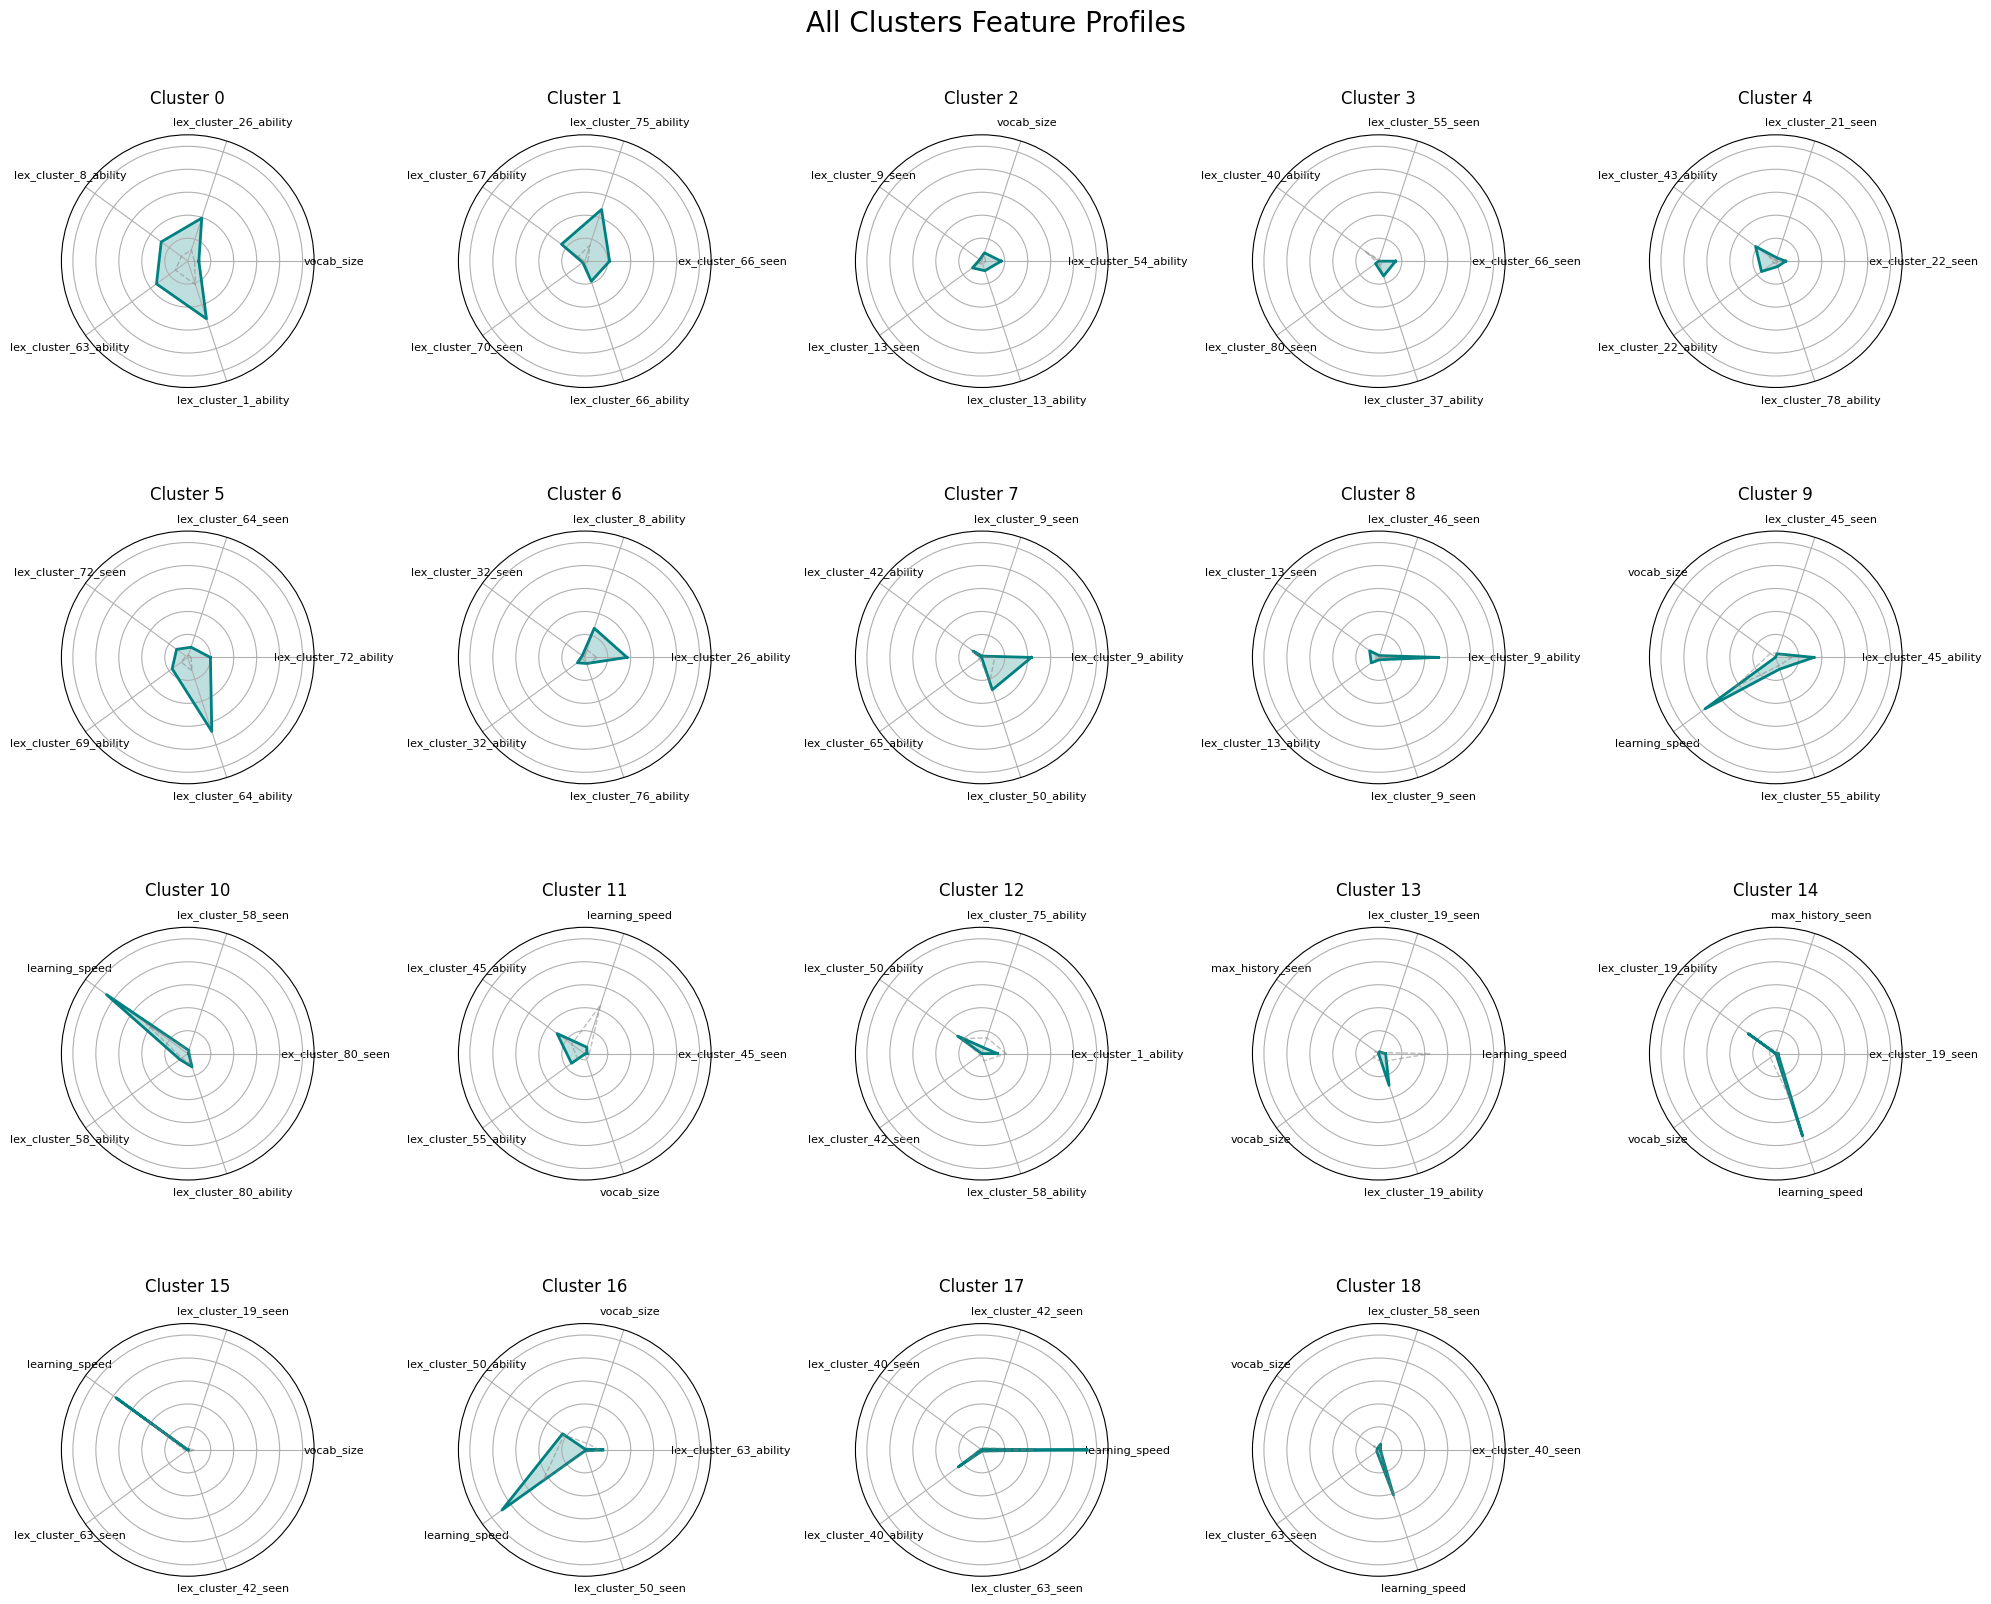

In [39]:
from src.evaluation.visualize import plot_cluster_top_features_radar, plot_all_clusters_radar_grid
plot_all_clusters_radar_grid(processed_df, importance_dict)

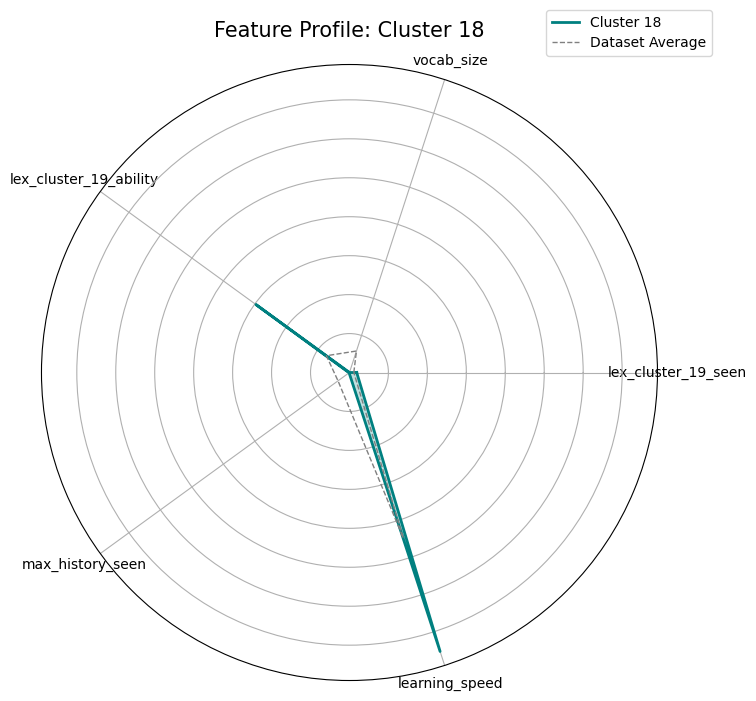

In [ ]:


# Cluster 18 using df_3
plot_cluster_top_features_radar(df_test, 18, importance_dict)

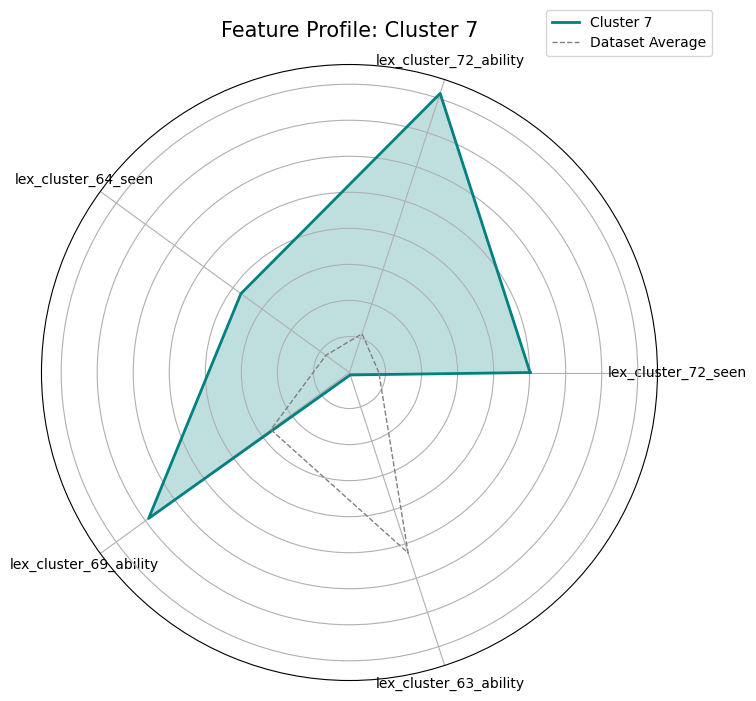

In [24]:
# Cluster 7 using df_3
plot_cluster_top_features_radar(processed_df, 7, importance_dict)